# 03 — Exploratory Data Analysis & Visualization
Understand seasonality, distributions, extremes, and relationships between variables —
this is what drives the ML-problem selection in notebook 04.

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)

df = pd.read_csv('../data/processed/jabalpur_clean.csv')
df['valid_time'] = pd.to_datetime(df['valid_time'])
df.shape

(17544, 24)

## Weather variables over time

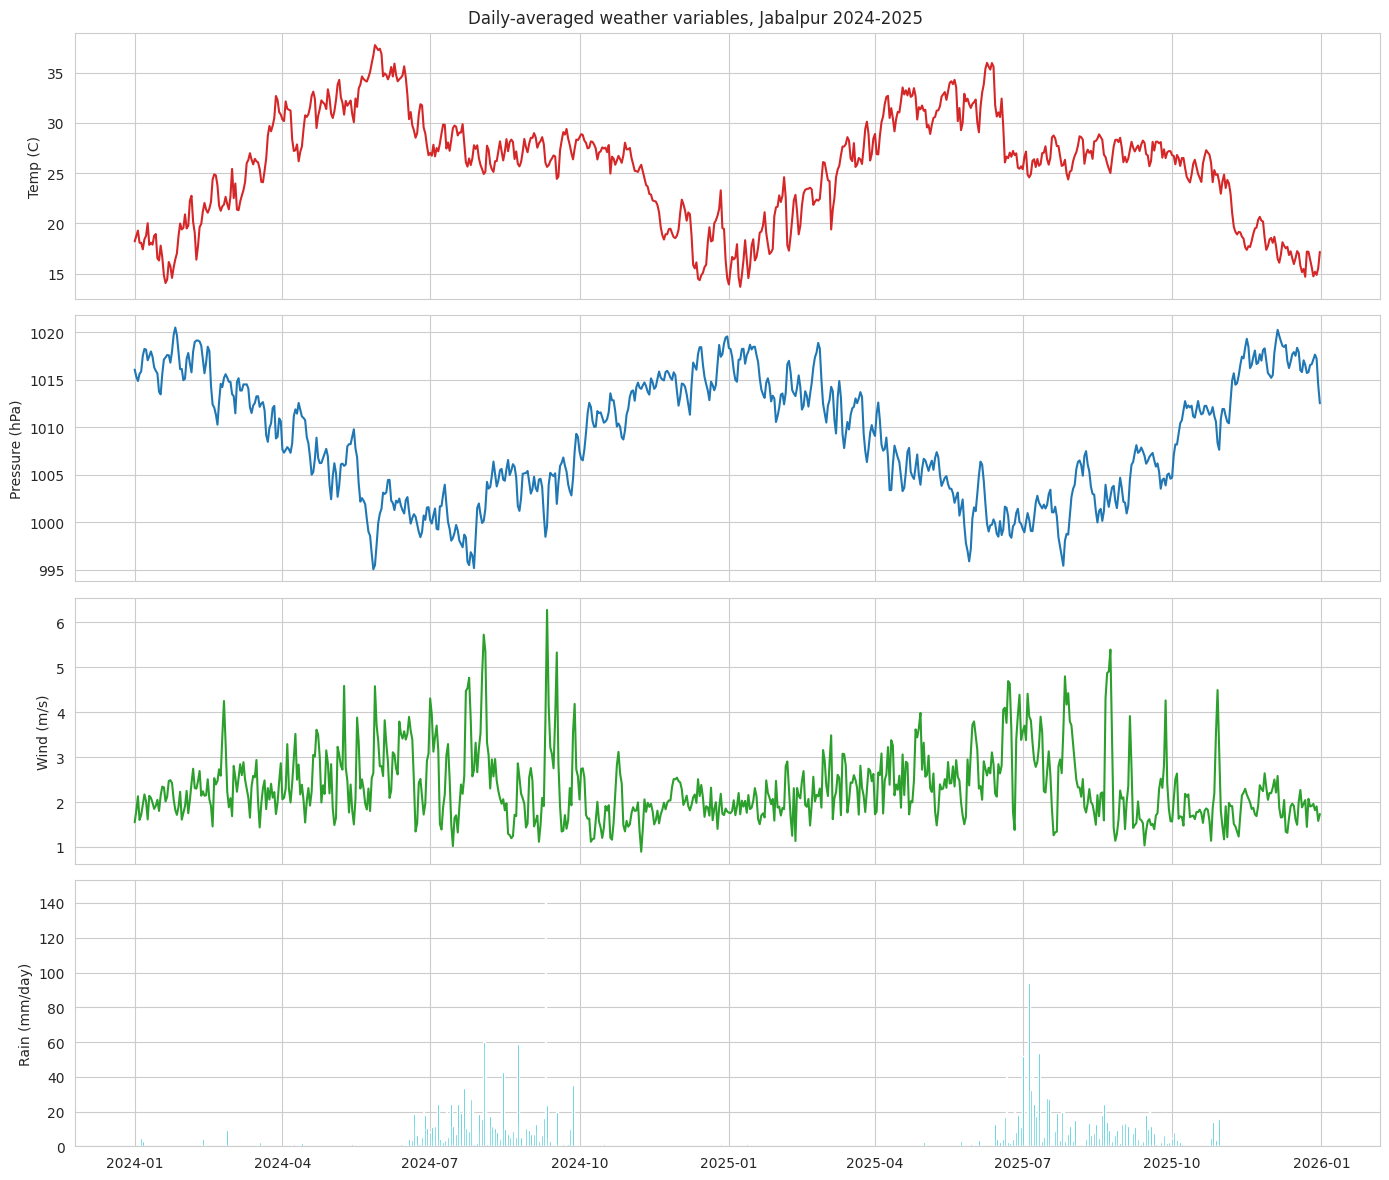

In [2]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
daily = df.set_index('valid_time').resample('D').mean(numeric_only=True)
axes[0].plot(daily.index, daily['t2m_c'], color='tab:red'); axes[0].set_ylabel('Temp (C)')
axes[1].plot(daily.index, daily['msl_hpa'], color='tab:blue'); axes[1].set_ylabel('Pressure (hPa)')
axes[2].plot(daily.index, daily['wind_speed'], color='tab:green'); axes[2].set_ylabel('Wind (m/s)')
daily_rain = df.set_index('valid_time')['tp_mm'].resample('D').sum()
axes[3].bar(daily_rain.index, daily_rain.values, color='tab:cyan', width=1); axes[3].set_ylabel('Rain (mm/day)')
plt.suptitle('Daily-averaged weather variables, Jabalpur 2024-2025')
plt.tight_layout()
plt.savefig('../reports/fig_timeseries_overview.png', dpi=120)
plt.show()

## Monthly rainfall (monsoon signature)

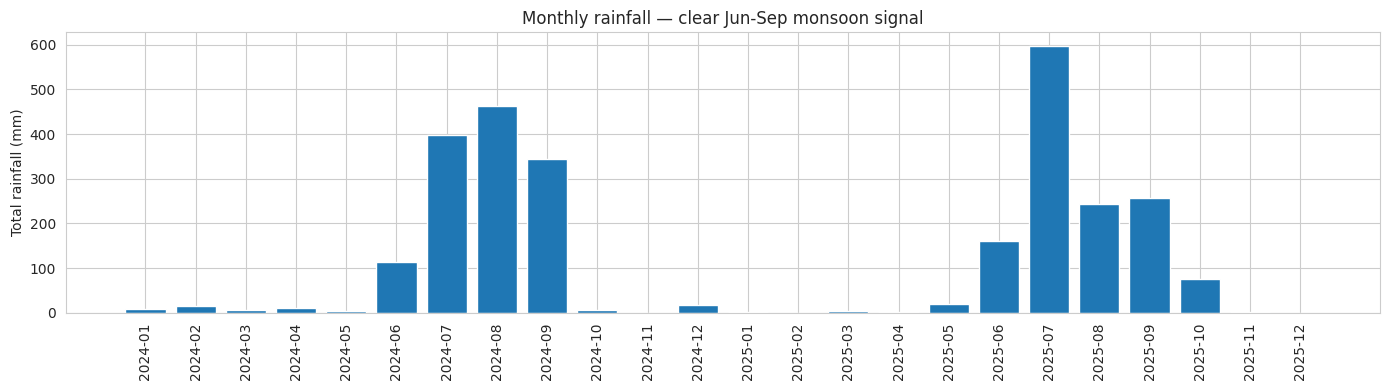

In [3]:
monthly_rain = df.set_index('valid_time')['tp_mm'].resample('ME').sum()
plt.figure(figsize=(14,4))
plt.bar(monthly_rain.index.strftime('%Y-%m'), monthly_rain.values, color='tab:blue')
plt.xticks(rotation=90)
plt.ylabel('Total rainfall (mm)')
plt.title('Monthly rainfall — clear Jun-Sep monsoon signal')
plt.tight_layout()
plt.savefig('../reports/fig_monthly_rainfall.png', dpi=120)
plt.show()

## Rainfall distribution (zero-inflated)

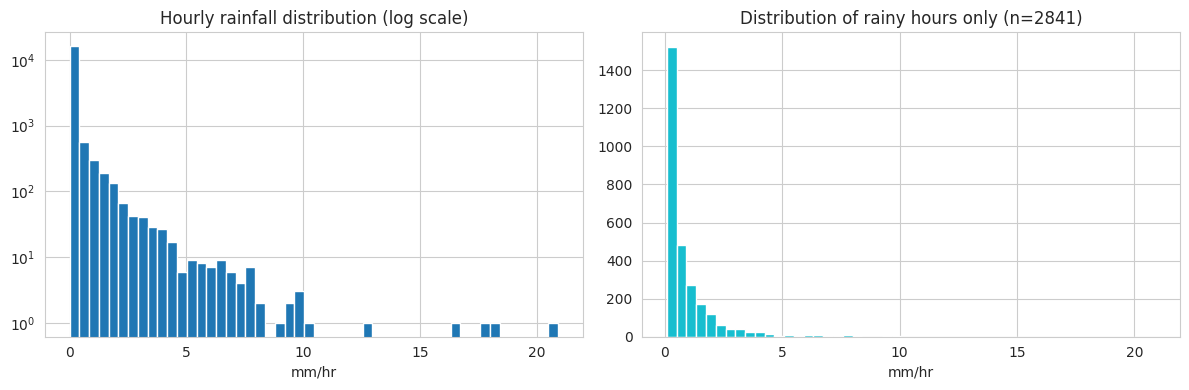

Zero-rain hours: 11852 / 17544 (67.6%)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(df['tp_mm'], bins=50, color='tab:blue')
axes[0].set_yscale('log')
axes[0].set_title('Hourly rainfall distribution (log scale)')
axes[0].set_xlabel('mm/hr')

nonzero = df.loc[df['tp_mm']>0.1, 'tp_mm']
axes[1].hist(nonzero, bins=50, color='tab:cyan')
axes[1].set_title(f'Distribution of rainy hours only (n={len(nonzero)})')
axes[1].set_xlabel('mm/hr')
plt.tight_layout()
plt.savefig('../reports/fig_rainfall_distribution.png', dpi=120)
plt.show()

print('Zero-rain hours:', (df['tp_mm']==0).sum(), '/', len(df),
      f"({(df['tp_mm']==0).mean()*100:.1f}%)")

## Temperature distribution & seasonality

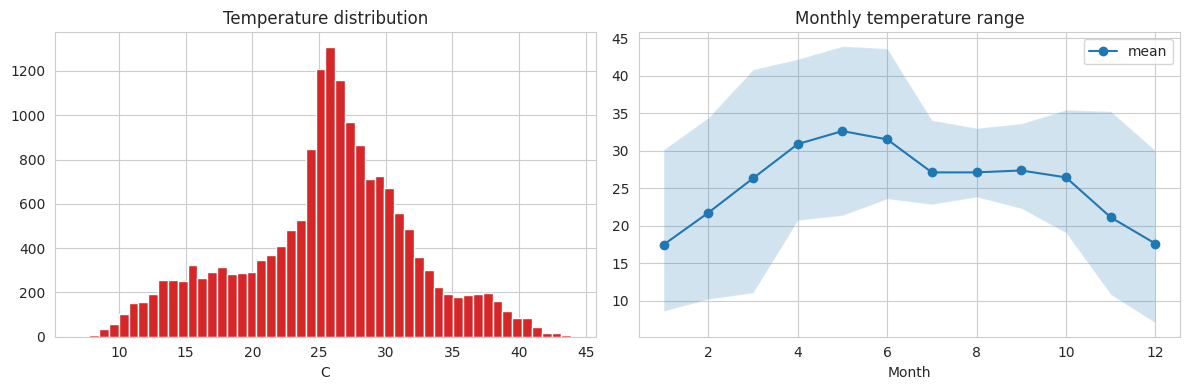

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(df['t2m_c'], bins=50, color='tab:red')
axes[0].set_title('Temperature distribution')
axes[0].set_xlabel('C')

monthly_temp = df.groupby(df['valid_time'].dt.month)['t2m_c'].agg(['mean','min','max'])
axes[1].plot(monthly_temp.index, monthly_temp['mean'], marker='o', label='mean')
axes[1].fill_between(monthly_temp.index, monthly_temp['min'], monthly_temp['max'], alpha=0.2)
axes[1].set_title('Monthly temperature range')
axes[1].set_xlabel('Month')
axes[1].legend()
plt.tight_layout()
plt.savefig('../reports/fig_temperature_distribution.png', dpi=120)
plt.show()

## Pressure distribution

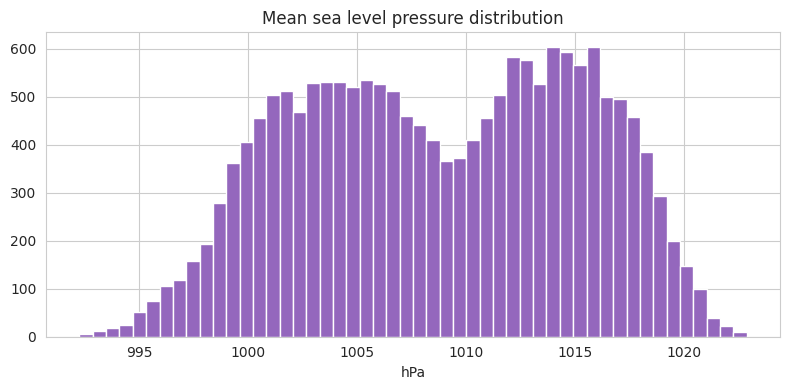

In [6]:
plt.figure(figsize=(8,4))
plt.hist(df['msl_hpa'], bins=50, color='tab:purple')
plt.title('Mean sea level pressure distribution')
plt.xlabel('hPa')
plt.tight_layout()
plt.savefig('../reports/fig_pressure_distribution.png', dpi=120)
plt.show()

## Wind characteristics

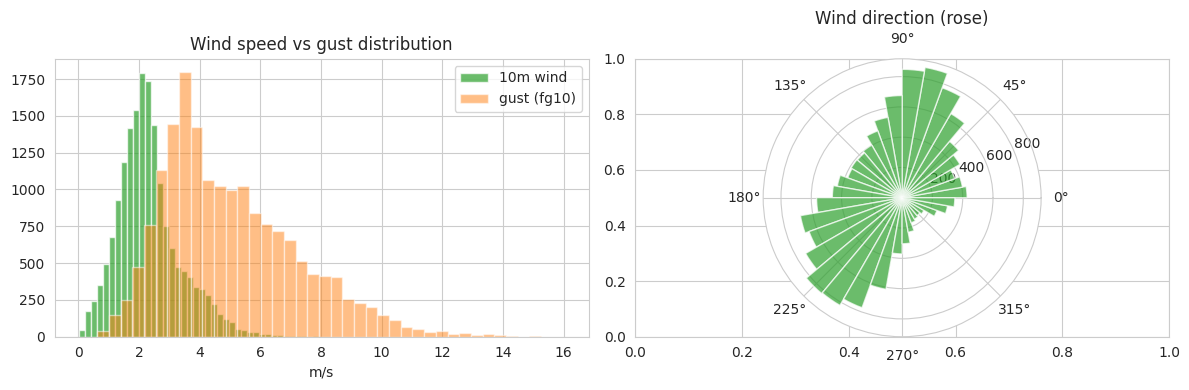

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(df['wind_speed'], bins=40, color='tab:green', alpha=0.7, label='10m wind')
axes[0].hist(df['fg10'], bins=40, color='tab:orange', alpha=0.5, label='gust (fg10)')
axes[0].legend(); axes[0].set_title('Wind speed vs gust distribution'); axes[0].set_xlabel('m/s')

ax = plt.subplot(1,2,2, projection='polar')
theta = np.radians(df['wind_dir_deg'])
ax.hist(theta, bins=36, color='tab:green', alpha=0.7)
ax.set_title('Wind direction (rose)')
plt.tight_layout()
plt.savefig('../reports/fig_wind_characteristics.png', dpi=120)
plt.show()

## Correlation matrix

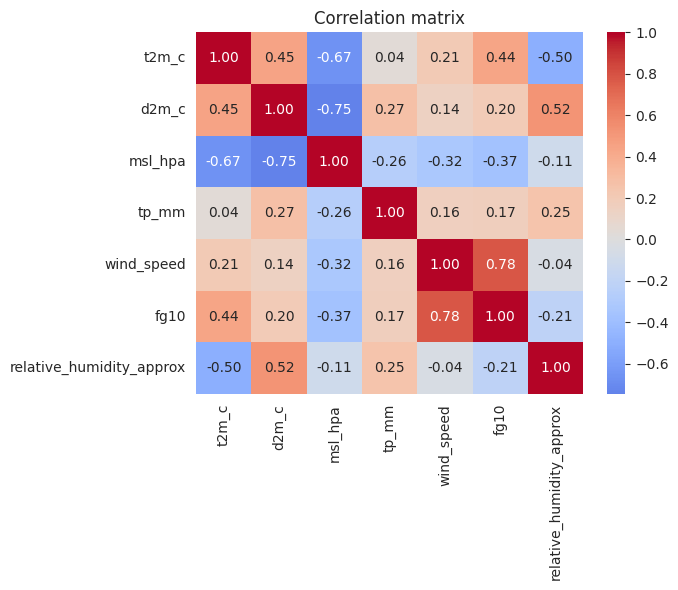

In [8]:
corr_cols = ['t2m_c','d2m_c','msl_hpa','tp_mm','wind_speed','fg10','relative_humidity_approx']
corr = df[corr_cols].corr()
plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.tight_layout()
plt.savefig('../reports/fig_correlation_matrix.png', dpi=120)
plt.show()

## Extreme weather events

In [9]:
daily_rain = df.set_index('valid_time')['tp_mm'].resample('D').sum()
print('Rainy days (>1mm):', (daily_rain>1).sum(), '/', len(daily_rain))
print('IMD heavy rain days (>64.5mm/day):')
print(daily_rain[daily_rain>64.5])
print()
print('Hottest hour:', df.loc[df['t2m_c'].idxmax(), ['valid_time','t2m_c']].to_dict())
print('Coldest hour:', df.loc[df['t2m_c'].idxmin(), ['valid_time','t2m_c']].to_dict())
print('Windiest hour:', df.loc[df['wind_speed'].idxmax(), ['valid_time','wind_speed','fg10']].to_dict())

Rainy days (>1mm): 229 / 731
IMD heavy rain days (>64.5mm/day):
valid_time
2024-09-10    145.745753
2025-07-05     93.840600
Name: tp_mm, dtype: float64

Hottest hour: {'valid_time': Timestamp('2024-05-27 09:00:00'), 't2m_c': 43.91488000000004}
Coldest hour: {'valid_time': Timestamp('2024-12-14 23:00:00'), 't2m_c': 7.042169999999999}
Windiest hour: {'valid_time': Timestamp('2025-08-24 08:00:00'), 'wind_speed': 7.951008933652615, 'fg10': 13.672147}


## Autocorrelation (justifies the forecasting problem in notebook 04)

In [10]:
for col in ['t2m_c','msl_hpa','wind_speed']:
    print(col, 'lag-1 autocorrelation:', round(df[col].autocorr(lag=1), 3))

t2m_c lag-1 autocorrelation: 0.975
msl_hpa lag-1 autocorrelation: 0.995
wind_speed lag-1 autocorrelation: 0.922


## Summary of Notebook 03
- Clear monsoon signature: ~85% of 2-year total rainfall falls in Jun-Sep
- Rainfall is heavily zero-inflated (84% of hours have zero precipitation)
- Only 2 days out of 731 cross the IMD heavy-rain threshold — too few positives for reliable extreme-event classification on this dataset alone
- Temperature shows very strong lag-1 autocorrelation (0.975) — a strong, clean forecasting signal
- Pressure anti-correlates with temperature (-0.67) and rainfall (-0.26), consistent with known meteorology
- Next: `04_feature_engineering.ipynb` and ML-problem selection